In [1]:
import os
import sys
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')


import brainstate
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Ion, MechanismProbe
from braincell.ion import CdpHVA_SU2015_DCN

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
repo_root = Path(braincell.__file__).resolve().parent.parent
mod_dir = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'DCN'
mod_file = mod_dir / 'ion' / 'CdpHVA_SU15_DCN.mod'
print('repo_root:', repo_root)
print('mod_dir:', mod_dir)
print('mod_file:', mod_file)
print(mod_file.read_text().split('DERIVATIVE states {', 1)[1].split('}', 1)[0])


repo_root: /home/swl/braincell-ion_dyn
mod_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/DCN
mod_file: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/DCN/ion/CdpHVA_SU15_DCN.mod

    C = (cai - caiBase) / tauCa
	D = - kCa / depth * ica * (1e4)
    cai' = D - C



In [3]:
from neuron import h, load_mechanisms

if not load_mechanisms(str(mod_dir.resolve())):
    raise RuntimeError(f'NEURON mechanisms not found under {mod_dir!s}; compile the DCN mods first.')
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = 20.0
sec.diam = 20.0
sec.nseg = 1
seg = sec(0.5)
sec.insert('CdpHVA_SU15_DCN')

h.tauCa_CdpHVA_SU15_DCN = 70.0
seg.CdpHVA_SU15_DCN.kCa = 3.45e-7
seg.CdpHVA_SU15_DCN.depth = 0.2
seg.cai = 50e-6

h.dt = 0.05
h.steps_per_ms = 1.0 / h.dt
h.tstop = 40.0
h.v_init = -60.0

t_vec = h.Vector().record(h._ref_t)
cai_vec = h.Vector().record(seg._ref_cai)
ica_vec = h.Vector().record(seg._ref_ica)

h.finitialize(h.v_init)
seg.cai = 80e-6
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_cai_mM = np.asarray(cai_vec)
neuron_ica_mA_cm2 = np.asarray(ica_vec)

print('max |ica|:', float(np.max(np.abs(neuron_ica_mA_cm2))))
print('cai[0], cai[-1]:', float(neuron_cai_mM[0]), float(neuron_cai_mM[-1]))


max |ica|: 0.0
cai[0], cai[-1]: 8e-05 6.693808490816598e-05


--No graphics will be displayed.


In [4]:
dt = 0.05 * u.ms
duration = 40.0 * u.ms
steps = int(duration / dt)
times_ms = np.arange(steps + 1) * float(dt.to_decimal(u.ms))

ion = CdpHVA_SU2015_DCN(
    size=1,
    tauCa=70.0 * u.ms,
    kCa=3.45e-7 / u.coulomb,
    depth=0.2 * u.um,
    caiBase=50e-6 * u.mM,
    Ci_initializer=80e-6 * u.mM,
)
V = jnp.array([-60.0]) * u.mV
ion.init_state(V)

bc_cai = [float(np.asarray(ion.Ci.value.to_decimal(u.mM)).reshape(-1)[0])]
for _ in range(steps):
    dci = ion.derivative(ion.Ci.value, V, total_current=None)
    ion.Ci.value = ion.Ci.value + dci * dt
    bc_cai.append(float(np.asarray(ion.Ci.value.to_decimal(u.mM)).reshape(-1)[0]))

bc_cai_mM = np.asarray(bc_cai)
print('Ci[0], Ci[-1]:', bc_cai_mM[0], bc_cai_mM[-1])


Ci[0], Ci[-1]: 8e-05 6.693808490816598e-05


In [5]:
soma = Branch.from_lengths(lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')
cell = Cell(morpho, solver='euler')
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Ion(
        'CdpHVA_SU2015_DCN',
        name='ca_cdp',
        tauCa=70.0 * u.ms,
        kCa=3.45e-7 / u.coulomb,
        depth=0.2 * u.um,
        caiBase=50e-6 * u.mM,
        Ci_initializer=80e-6 * u.mM,
    ),
)
cell.place(at('soma', 0.5), MechanismProbe(mechanism='ca_cdp', field='Ci'))
with brainstate.environ.context(precision=64):
    cell.init_state()
runtime_ion = cell.get_ion('ca_cdp')
print('initial probe Ci (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cdp_Ci').to_decimal(u.mM)).reshape(-1)[0]))
with brainstate.environ.context(precision=64, dt=0.05 * u.ms):
    cell.compute_derivative()
print('runtime dCi/dt (mM/ms):', float(np.asarray(runtime_ion.Ci.derivative.to_decimal(u.mM / u.ms)).reshape(-1)[0]))

cell_run = Cell(morpho, solver='euler')
cell_run.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Ion(
        'CdpHVA_SU2015_DCN',
        name='ca_cdp',
        tauCa=70.0 * u.ms,
        kCa=3.45e-7 / u.coulomb,
        depth=0.2 * u.um,
        caiBase=50e-6 * u.mM,
        Ci_initializer=80e-6 * u.mM,
    ),
)
cell_run.place(at('soma', 0.5), MechanismProbe(mechanism='ca_cdp', field='Ci'))
with brainstate.environ.context(precision=64):
    cell_run.init_state()
    run_result = cell_run.run(dt=0.05 * u.ms, duration=40.0 * u.ms)
cell_cai_mM = np.asarray(run_result.traces['soma(0.5)_ca_cdp_Ci'].to_decimal(u.mM))
print('Cell trace start/end (mM):', float(cell_cai_mM[0]), float(cell_cai_mM[-1]))


initial probe Ci (mM): 8e-05
runtime dCi/dt (mM/ms): 0.0
Cell trace start/end (mM): 7.997857142857144e-05 6.693808490816598e-05


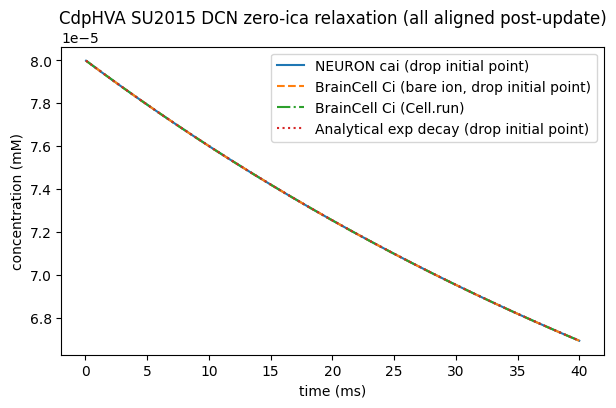

NEURON vs analytical (drop initial point): {'mae': 2.114014146850934e-09, 'rmse': 2.335430716496558e-09, 'max_abs': 3.4587520668041436e-09}
BrainCell bare ion vs analytical (drop initial point): {'mae': 2.114014146850934e-09, 'rmse': 2.335430716496558e-09, 'max_abs': 3.4587520668041436e-09}
BrainCell Cell.run vs analytical (same aligned axis): {'mae': 2.114014146850934e-09, 'rmse': 2.335430716496558e-09, 'max_abs': 3.4587520668041436e-09}


In [6]:
analytical = 50e-6 + (80e-6 - 50e-6) * np.exp(-times_ms / 70.0)

compare_t_ms = times_ms[1:]
neuron_compare = neuron_cai_mM[1:]
bare_compare = bc_cai_mM[1:]
cell_compare = cell_cai_mM
analytical_compare = analytical[1:]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

err_neuron = summarize_error(neuron_compare, analytical_compare)
err_bare = summarize_error(bare_compare, analytical_compare)
err_cell = summarize_error(cell_compare, analytical_compare[:len(cell_compare)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(compare_t_ms[:len(neuron_compare)], neuron_compare, label='NEURON cai (drop initial point)')
ax.plot(compare_t_ms[:len(bare_compare)], bare_compare, '--', label='BrainCell Ci (bare ion, drop initial point)')
ax.plot(compare_t_ms[:len(cell_compare)], cell_compare, '-.', label='BrainCell Ci (Cell.run)')
ax.plot(compare_t_ms[:len(analytical_compare)], analytical_compare, ':', label='Analytical exp decay (drop initial point)')
ax.set_xlabel('time (ms)')
ax.set_ylabel('concentration (mM)')
ax.set_title('CdpHVA SU2015 DCN zero-ica relaxation (all aligned post-update)')
ax.legend()
plt.show()

print('NEURON vs analytical (drop initial point):', err_neuron)
print('BrainCell bare ion vs analytical (drop initial point):', err_bare)
print('BrainCell Cell.run vs analytical (same aligned axis):', err_cell)
